In [26]:
#This project analyzes Superstore sales data to uncover insights related to profitability, customer behavior, and regional performance.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Superstore.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,...,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3,10/13/2010,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,...,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010
1,49,293,10-01-2012,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10-02-2012
2,50,293,10-01-2012,High,27,244.5700,0.01,Regular Air,46.71,8.69,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D® Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10-03-2012
3,80,483,07-10-2011,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,...,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,07-12-2011
4,85,515,8/28/2010,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,...,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,8/30/2010


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Row ID                8399 non-null   int64  
 1   Order ID              8399 non-null   int64  
 2   Order Date            8399 non-null   object 
 3   Order Priority        8399 non-null   object 
 4   Order Quantity        8399 non-null   int64  
 5   Sales                 8399 non-null   float64
 6   Discount              8399 non-null   float64
 7   Ship Mode             8399 non-null   object 
 8   Profit                8399 non-null   float64
 9   Unit Price            8399 non-null   float64
 10  Shipping Cost         8399 non-null   float64
 11  Customer Name         8399 non-null   object 
 12  Province              8399 non-null   object 
 13  Region                8399 non-null   object 
 14  Customer Segment      8399 non-null   object 
 15  Product Category     

In [5]:
df.describe()

,Row ID,Order ID,Order Quantity,Sales,Discount,Profit,Unit Price,Shipping Cost,Product Base Margin
count,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8336.000000
mean,4200.000000,29965.179783,25.571735,1775.878179,0.049671,181.184424,89.346259,12.838557,0.512513
std,2424.726789,17260.883447,14.481071,3585.050525,0.031823,1196.653371,290.354383,17.264052,0.135589
min,1.000000,3.000000,1.000000,2.240000,0.000000,-14140.700000,0.990000,0.490000,0.350000
25%,2100.500000,15011.500000,13.000000,143.195000,0.020000,-83.315000,6.480000,3.300000,0.380000
50%,4200.000000,29857.000000,26.000000,449.420000,0.050000,-1.500000,20.990000,6.070000,0.520000
75%,6299.500000,44596.000000,38.000000,1709.320000,0.080000,162.750000,85.990000,13.990000,0.590000
max,8399.000000,59973.000000,50.000000,89061.050000,0.250000,27220.690000,6783.020000,164.730000,0.850000


In [6]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Order Priority,0
Order Quantity,0
Sales,0
Discount,0
Ship Mode,0
Profit,0
Unit Price,0


In [7]:
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())

Total Sales: 14915600.824000001
Total Profit: 1521767.98


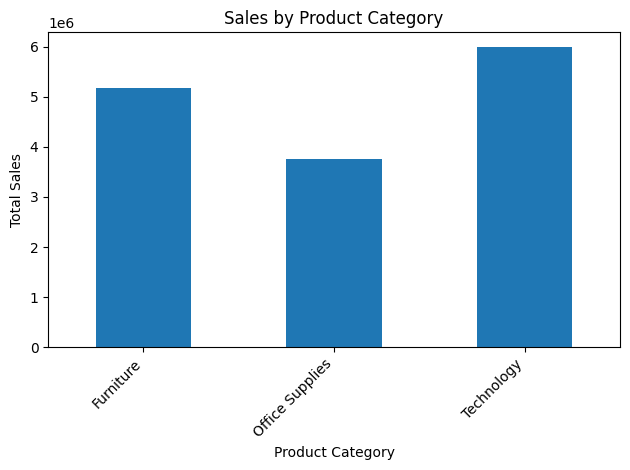

In [11]:
Category_sales = df.groupby("Product Category")["Sales"].sum()

Category_sales.plot(kind="bar")
plt.title("Sales by Product Category")
plt.ylabel("Total Sales")
plt.xlabel("Product Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

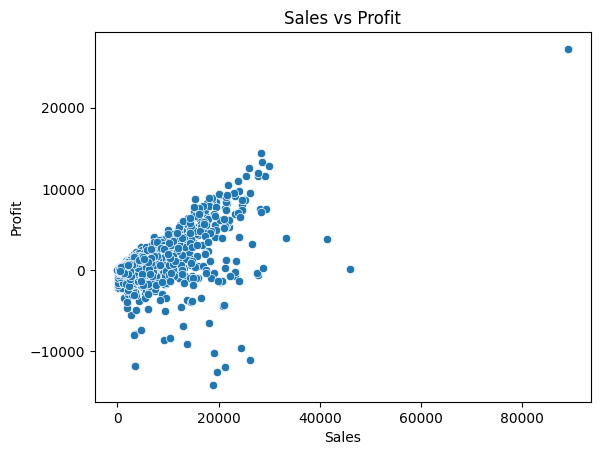

In [12]:
sns.scatterplot(x="Sales", y="Profit", data=df)
plt.title("Sales vs Profit")
plt.show()

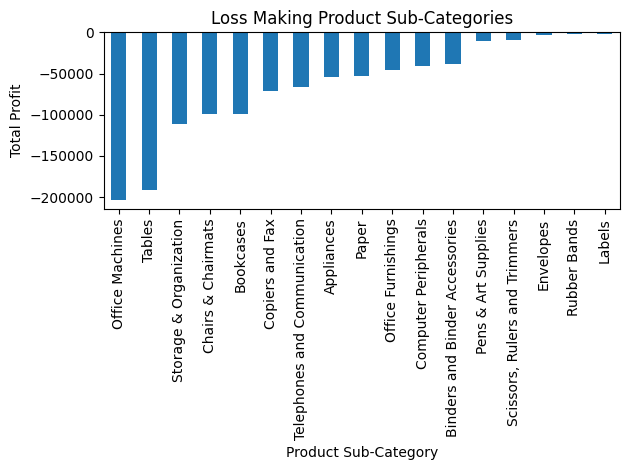

In [14]:
loss_df = df[df["Profit"] < 0]

loss_products = loss_df.groupby("Product Sub-Category")["Profit"].sum().sort_values()

loss_products.plot(kind="bar")
plt.title("Loss Making Product Sub-Categories")
plt.ylabel("Total Profit")
plt.xlabel("Product Sub-Category")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

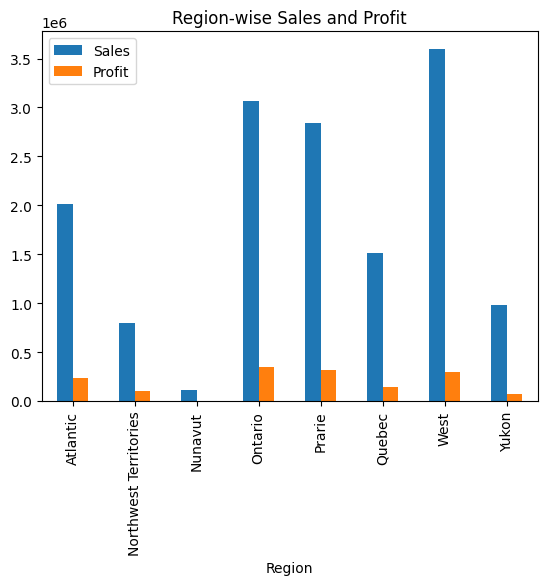

In [15]:
region_sales = df.groupby("Region")[["Sales","Profit"]].sum()
region_sales.plot(kind="bar")
plt.title("Region-wise Sales and Profit")
plt.show()

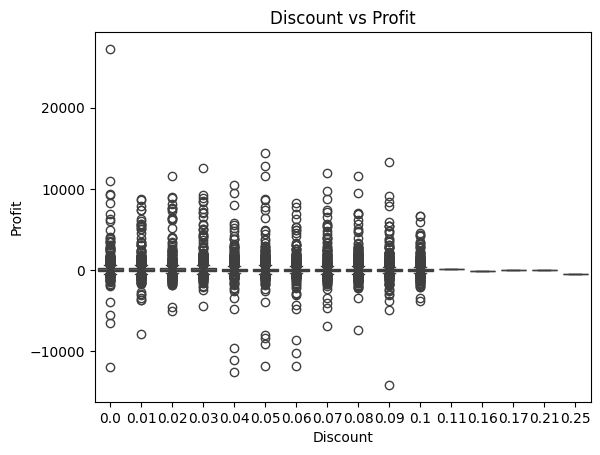

In [16]:
sns.boxplot(x="Discount", y="Profit", data=df)
plt.title("Discount vs Profit")
plt.show()

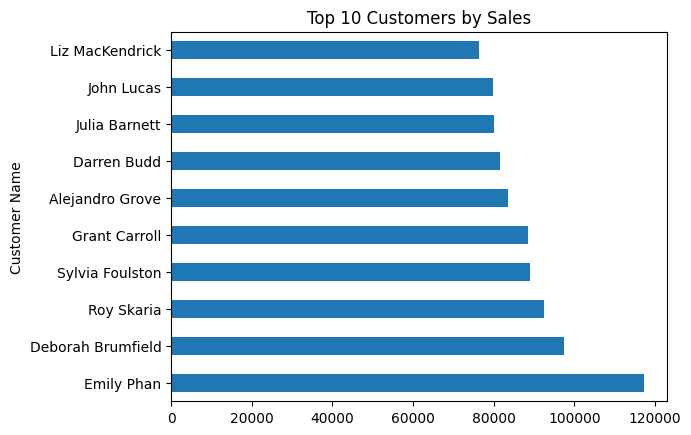

In [17]:
top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind="barh")
plt.title("Top 10 Customers by Sales")
plt.show()

In [18]:
df["Profit Margin"] = (df["Profit"] / df["Sales"]) * 100

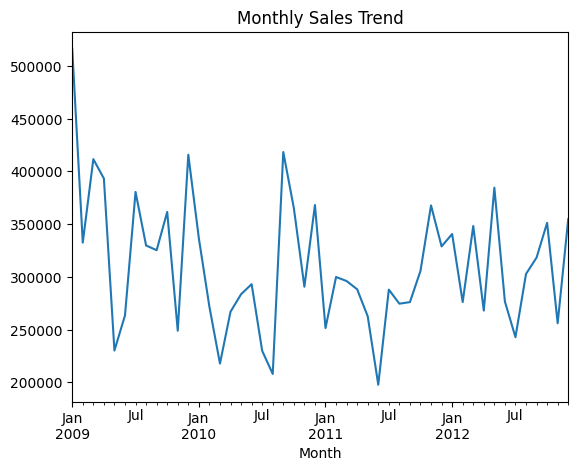

In [20]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format='mixed')

df["Month"] = df["Order Date"].dt.to_period("M")

monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales.plot(kind="line")
plt.title("Monthly Sales Trend")
plt.show()

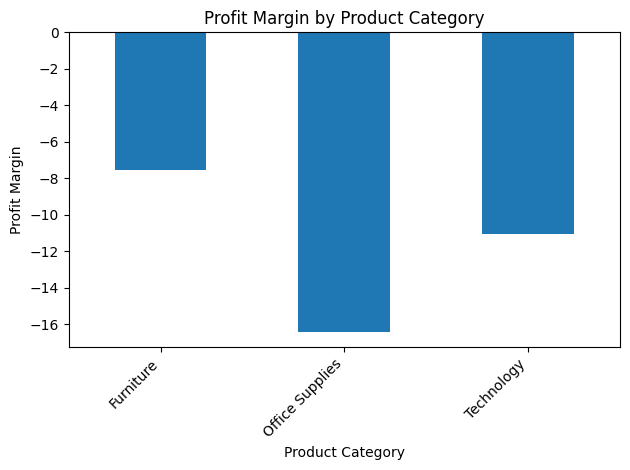

In [22]:
category_margin = df.groupby("Product Category")["Profit Margin"].mean()

category_margin.plot(kind="bar")
plt.title("Profit Margin by Product Category")
plt.ylabel("Profit Margin")
plt.xlabel("Product Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [23]:
worst_orders = df.sort_values("Profit").head(5)

worst_orders[["Product Name","Sales","Profit","Discount"]]

,Product Name,Sales,Profit,Discount
8313,Polycom ViewStation™ ISDN Videoconferencing Unit,18888.00,-14140.70,0.09
7677,Polycom ViewStation™ ISDN Videoconferencing Unit,19707.20,-12558.00,0.04
7968,Polycom ViewStation™ ISDN Videoconferencing Unit,21366.51,-11984.40,0.00
5913,Canon imageCLASS 2200 Advanced Copier,3457.99,-11861.46,0.05
4661,Canon imageCLASS 2200 Advanced Copier,3550.28,-11769.17,0.06


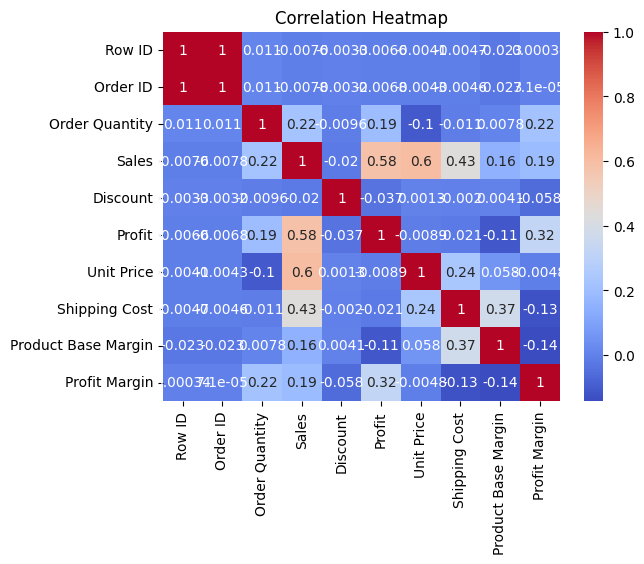

In [25]:
df.columns = df.columns.str.strip()

corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# KEY INSIGHTS
#- High sales do not guarantee profitability due to excessive discounting.
#- Furniture category shows consistent losses.
#- Technology category has the highest profit margin.
#- Certain regions underperform despite strong sales.
#- A small group of customers contributes significantly to total revenue.